In [1]:
%load_ext autoreload
%autoreload 2
from asn.data.reasoning_graph import ReasoningGraph
from ground_slash.program import Program

# Normal rules

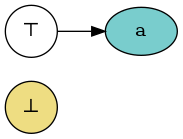

In [2]:
# normal fact
ReasoningGraph(Program.from_string("""
a.
""")).draw(direction="LR")

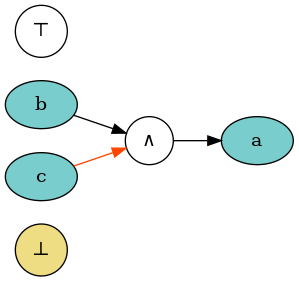

In [3]:
# normal rule w/ default negation
ReasoningGraph(Program.from_string("""
a :- b, not c.
""")).draw(direction="LR")

# Constraints

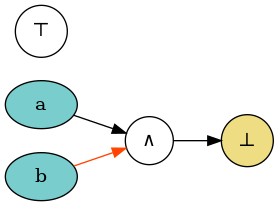

In [4]:
# constraint w/ default-negation
ReasoningGraph(Program.from_string("""
:- a, not b.
""")).draw(direction="LR")

# Disjunctive rules

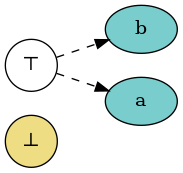

In [5]:
# disjunctive fact
ReasoningGraph(Program.from_string("""
a | b.
""")).draw(direction="LR")

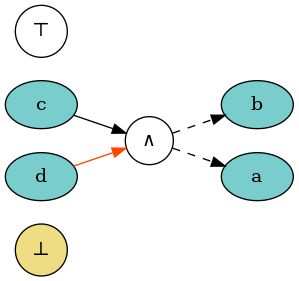

In [6]:
# disjunctive rule w/ default-negation
ReasoningGraph(Program.from_string("""
a | b :- c, not d.
""")).draw(direction="LR")

# Choice rules

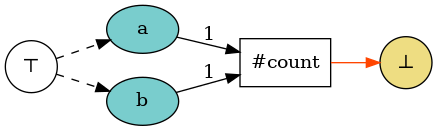

In [7]:
# choice fact w/o extra conditions
ReasoningGraph(Program.from_string("""
{a; a; b}.
""")).draw(direction="LR")

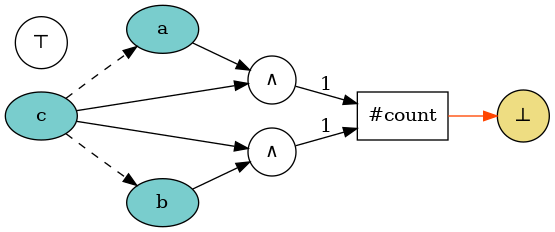

In [8]:
# choice fact w/ extra conditions
ReasoningGraph(Program.from_string("""
{a:c; a:c,d; b:c}.
""")).draw(direction="LR")

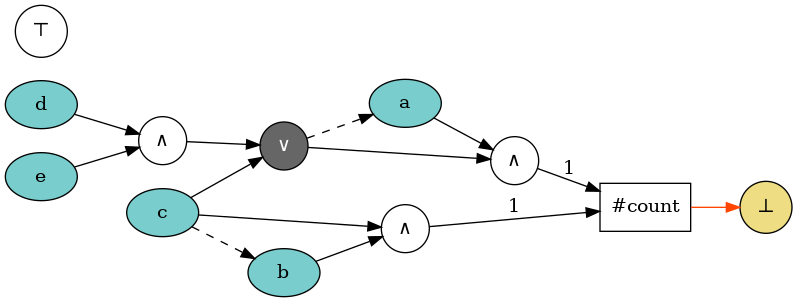

In [9]:
# choice fact w/ multiple extra conditions
ReasoningGraph(Program.from_string("""
{a:c; a:d,e; b:c}.
""")).draw(direction="LR")

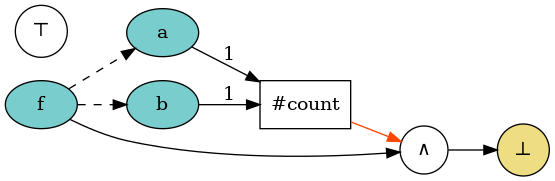

In [10]:
# choice rule w/o extra conditions
ReasoningGraph(Program.from_string("""
{a; a; b} :- f.
""")).draw(direction="LR")

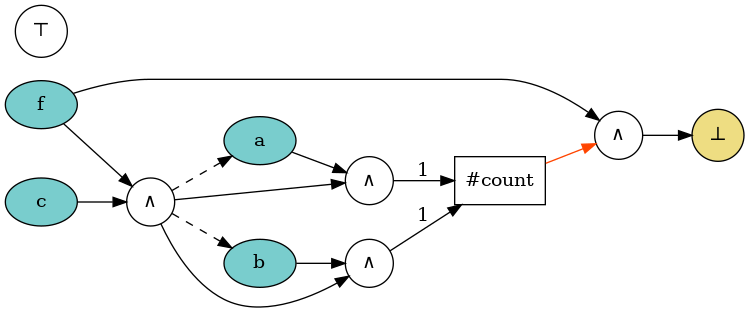

In [11]:
# choice rule w/ extra conditions
ReasoningGraph(Program.from_string("""
{a:c; a:c,d; b:c} :- f.
""")).draw(direction="LR")

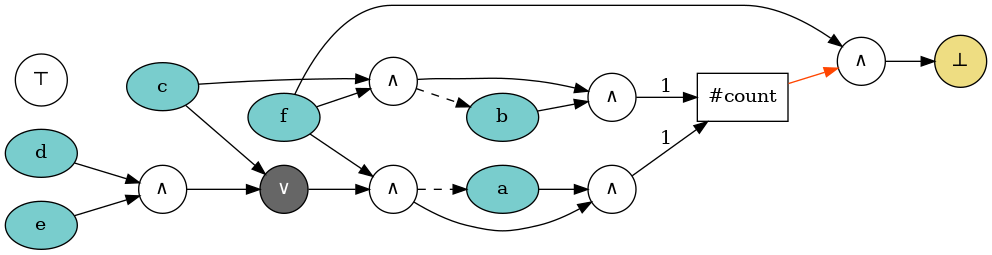

In [12]:
# choice rule w/ multiple extra condition
ReasoningGraph(Program.from_string("""
{a:c; a:d,e; b:c} :- f.
""")).draw(direction="LR")

# NPP rules

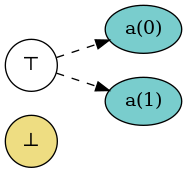

In [13]:
# NPP fact
ReasoningGraph(Program.from_string("""
#npp(a, [0,1]).
""")).draw(direction="LR")

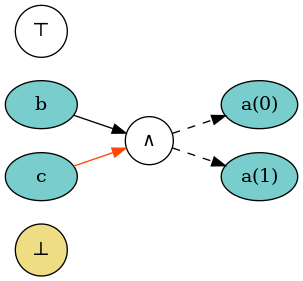

In [14]:
# NPP rule w/ default-negation
ReasoningGraph(Program.from_string("""
#npp(a, [0,1]) :- b, not c.
""")).draw(direction="LR")

# Aggregates

['1', '1', '2']


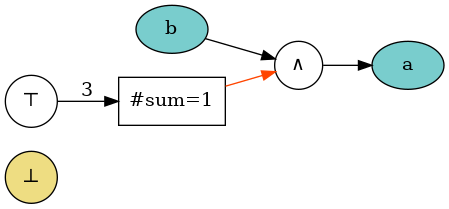

In [15]:
# aggregate w/o extra conditions
ReasoningGraph(Program.from_string("""
a :- b, not #sum{1; 1; 2}=1.
""")).draw(direction="LR")

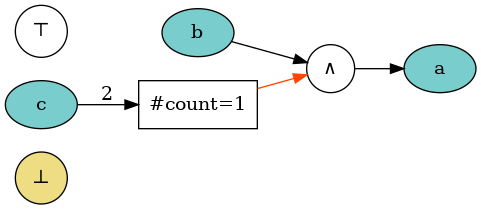

In [16]:
# aggregate w/ extra conditions
ReasoningGraph(Program.from_string("""
a :- b, not #count{e:c; e:c,d; f:c}=1.
""")).draw(direction="LR")

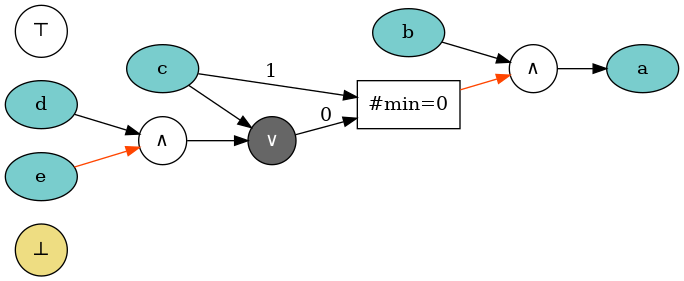

In [17]:
# aggregate w/ multiple extra conditions
ReasoningGraph(Program.from_string("""
a :- b, not #min{1:c; 1:d,not e; 2:c}=1.
""")).draw(direction="LR")

['1']


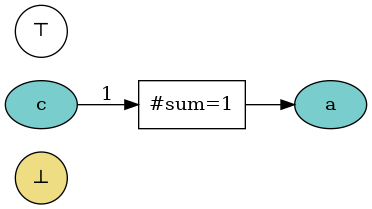

In [18]:
# sum aggregate with non-integer and zero terms
ReasoningGraph(Program.from_string("""
a :- #sum{1:c; 0:d,not e; a:c}=1.
""")).draw(direction="LR")

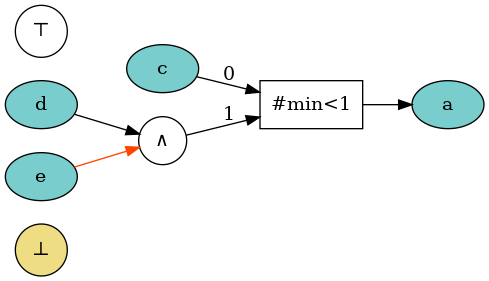

In [19]:
# min/max aggregate with non-integer terms and bounds
ReasoningGraph(Program.from_string("""
a :- #min{x:c; y:d,not e; z:c}<y.
""")).draw(direction="LR")

# Strong/classical negation

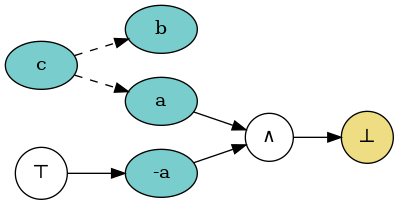

In [20]:
# atom & strong negation present simultaneously
ReasoningGraph(Program.from_string("""
a | b :- c.
-a.
""")).draw(direction="LR")

# Queries

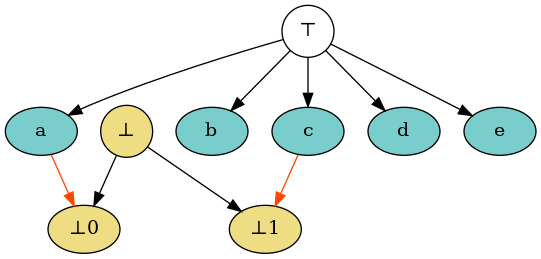

In [21]:
# two distinct simple queries
from ground_slash.program import Constraint, Naf, PredLiteral

rg = ReasoningGraph(Program.from_string(r"""
a.b.c.d.e.
"""))

# :- not a.
rg.encode_query(
    Constraint(Naf(PredLiteral('a')))
)
# :- not b.
rg.encode_query(
    Constraint(Naf(PredLiteral('c'))),
)

rg.draw(direction="TB")

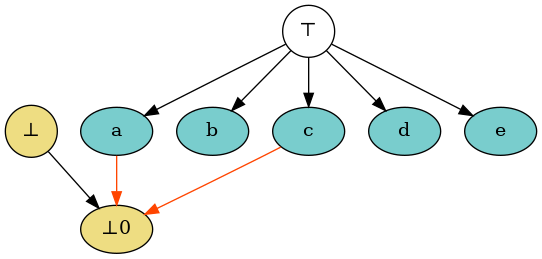

In [22]:
# multi-query
from ground_slash.program import Constraint, Naf, PredLiteral

rg = ReasoningGraph(Program.from_string(r"""
a.b.c.d.e.
"""))

rg.encode_query(
    (
        Constraint(Naf(PredLiteral('a'))),
        Constraint(Naf(PredLiteral('c'))),
    )
)

rg.draw(direction="TB")